# Read Data from the database

This notebook reads the data from the SQLite-Database and shows the data as a table or a diagram

## 1. Connection to the Database

In [16]:
import sqlite3
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to the database (relative to Project/utils/)
DB_PATH = Path("../data/database.db")

if not DB_PATH.exists():
    print(f"Couldn't find database: {DB_PATH.resolve()}")
else:
    print(f"Database found: {DB_PATH.resolve()}")

Database found: C:\Users\Justin Hennig\Documents\Praktikum2026\Praktikum2026\Project\data\database.db


## 2. Show every measurent_setting

In [17]:
with sqlite3.connect(DB_PATH) as con:
    df_settings = pd.read_sql_query("SELECT * FROM measurement_settings", con)

df_settings["configuration"] = df_settings["configuration"].apply(json.loads)
df_settings

,measurement_id,date_time,name,device,configuration
0,9,2026-03-25 10:15:15,Test 2,USB0::0xF4EC::0x1008::SDS5XHEC6R0118::INSTR,"{'Channel': 1, 'v_div_mv': '500.0000', 't_div_..."
1,10,,Test 2,Unknown,{}


## 3. Show the all the data according to the measurement_id

Choose the measurement_id from the table above to show the assiociated data

In [18]:
# Insert desired measurement_id here
MEASUREMENT_ID = 9

with sqlite3.connect(DB_PATH) as con:
    df_raw = pd.read_sql_query(
        "SELECT time, measurement_values FROM measurements WHERE measurement_id = ?",
        con,
        params=(MEASUREMENT_ID,),
    )

# Split measurement_values (JSON string) into separate columns
df_values = df_raw["measurement_values"].apply(json.loads).apply(pd.Series)
df = pd.concat([df_raw["time"], df_values], axis=1)

# Convert numeric columns to float
for col in df_values.columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    if converted.notna().any():  # Only replace if at least one valid numeric value is present
        df[col] = converted

print(f"Measurement Series {MEASUREMENT_ID} — {len(df)} Entries")
df

Measurement Series 9 — 3 Entries


,time,Frequency,Amplitude,Peak-to-Peak,RMS
0,1.40754,1100.0,2.050,2.050,0.7099
1,2.41405,1100.0,1.983,2.033,0.7098
2,3.46679,1100.0,2.050,2.050,0.7099


## 4. Visualize the data with matplotlib

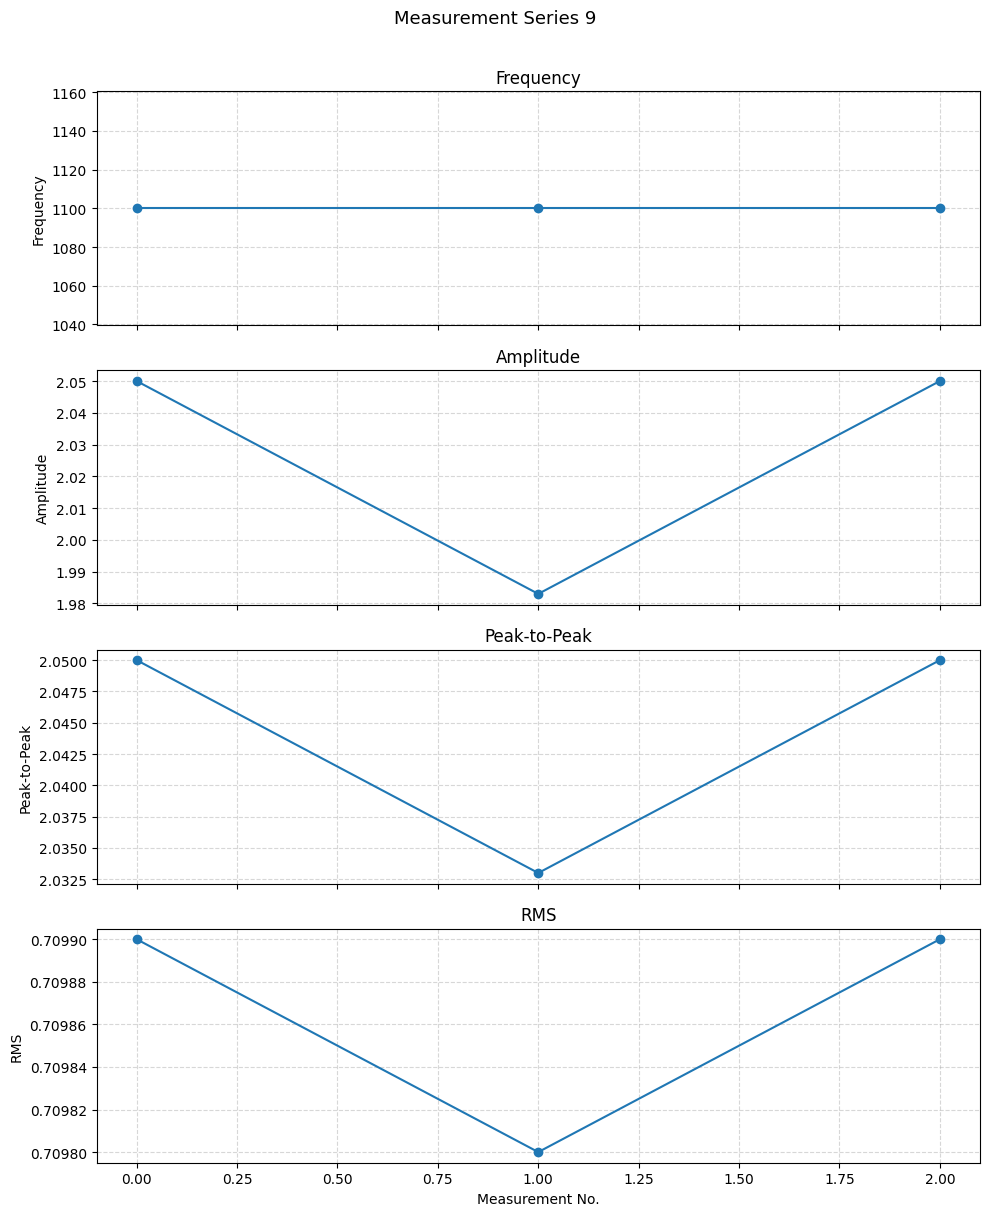

In [19]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

if not numeric_cols:
    print("No numeric columns found for plotting.")
else:
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3 * len(numeric_cols)), sharex=True)
    if len(numeric_cols) == 1:
        axes = [axes]

    x = range(len(df))
    for ax, col in zip(axes, numeric_cols):
        ax.plot(x, df[col], marker="o", linewidth=1.5)
        ax.set_ylabel(col)
        ax.set_title(col)
        ax.grid(True, linestyle="--", alpha=0.5)

    axes[-1].set_xlabel("Measurement No.")
    fig.suptitle(f"Measurement Series {MEASUREMENT_ID}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()